In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

In [26]:
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

## Load dataset

In [3]:
# Check where to import data from - if on colab then get it from the shared folder, otherwise from the relative local directory
import sys
if 'google.colab' in sys.modules:
    print("Running on Google Colab")

    from google.colab import drive
    drive.mount('/content/drive')

    df_zillow = pd.read_csv('/content/drive/MyDrive/MLBA/DS644-MLBA-Final-Project/data/master_zillow_with_taxes.csv')

else:
    print("Not running on Google Colab")
    df_zillow = pd.read_csv('../data/zillow_cleaned.csv')


Running on Google Colab
Mounted at /content/drive


In [4]:
df_zillow

,Unnamed: 0,zpid,address,price,beds,baths,area_sqft,latitude,longitude,status,...,state_code,zipcode,state_name,state_avg_housing_value,state_avg_prop_tax_rate,med_prop_tax_paid,single_filer_rates,single_filer_brackets,married_filing_jointly_rates,married_filing_jointly_brackets
0,0,17264897,"979 Kevin Ave, Redlands, CA 92373",447000,3,2.0,1300.0,34.040520,-117.186195,House for sale,...,CA,92373,California,604112.0690,0.688448,4024.142857,9.30,72724.0,9.30,145448.0
1,1,20021372,"13114 Addison St, Sherman Oaks, CA 91423",2795000,4,5.0,2900.0,34.160885,-118.418770,House for sale,...,CA,91423,California,604112.0690,0.688448,4024.142857,9.30,72724.0,9.30,145448.0
2,2,20009320,"6032 Goodland Ave, North Hollywood, CA 91606",1718000,4,3.0,3025.0,34.180450,-118.411280,House for sale,...,CA,91606,California,604112.0690,0.688448,4024.142857,9.30,72724.0,9.30,145448.0
3,3,460204882,"3325 Tonopah St, Oceanside, CA 92054",899999,3,3.0,1682.0,33.214260,-117.341500,Coming soon,...,CA,92054,California,604112.0690,0.688448,4024.142857,9.30,72724.0,9.30,145448.0
4,4,20769150,"963 Pine Grove Ave, Los Angeles, CA 90042",995000,2,2.0,1271.0,34.132890,-118.186220,House for sale,...,CA,90042,California,604112.0690,0.688448,4024.142857,9.30,72724.0,9.30,145448.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,2209,460202745,"111 Beechwood Ests, Scott Depot, WV 25560",499900,5,3.0,3651.0,38.444412,-81.925500,House for sale,...,WV,25560,West Virginia,148003.6364,0.458727,726.927273,4.82,60000.0,4.82,60000.0
2155,2210,23058172,"390 Dolly Ln, Dryfork, WV 26263",199000,2,1.0,1000.0,38.971350,-79.404600,House for sale,...,WV,26263,West Virginia,148003.6364,0.458727,726.927273,4.82,60000.0,4.82,60000.0
2156,2211,22336003,"1107 New York Ave, Martinsburg, WV 25401",249900,3,2.0,984.0,39.446636,-77.976555,House for sale,...,WV,25401,West Virginia,148003.6364,0.458727,726.927273,4.82,60000.0,4.82,60000.0
2157,2212,22907826,"2009 Ices Ferry Dr, Morgantown, WV 26508",1195000,5,5.0,5945.0,39.661613,-79.846214,House for sale,...,WV,26508,West Virginia,148003.6364,0.458727,726.927273,4.82,60000.0,4.82,60000.0


In [5]:
# Drop irrelevant/duplicate columns
df_zillow.drop(inplace=True, columns=[
    'detail_url',
    'address',
    'zpid',
    'Unnamed: 0',
    'street_add',
    'state_zipcode',
])

df_zillow

,price,beds,baths,area_sqft,latitude,longitude,status,home_type,days_on_zillow,zestimate,...,state_code,zipcode,state_name,state_avg_housing_value,state_avg_prop_tax_rate,med_prop_tax_paid,single_filer_rates,single_filer_brackets,married_filing_jointly_rates,married_filing_jointly_brackets
0,447000,3,2.0,1300.0,34.040520,-117.186195,House for sale,SINGLE_FAMILY,5,455500.0,...,CA,92373,California,604112.0690,0.688448,4024.142857,9.30,72724.0,9.30,145448.0
1,2795000,4,5.0,2900.0,34.160885,-118.418770,House for sale,SINGLE_FAMILY,8,NaN,...,CA,91423,California,604112.0690,0.688448,4024.142857,9.30,72724.0,9.30,145448.0
2,1718000,4,3.0,3025.0,34.180450,-118.411280,House for sale,SINGLE_FAMILY,8,1695500.0,...,CA,91606,California,604112.0690,0.688448,4024.142857,9.30,72724.0,9.30,145448.0
3,899999,3,3.0,1682.0,33.214260,-117.341500,Coming soon,SINGLE_FAMILY,4,NaN,...,CA,92054,California,604112.0690,0.688448,4024.142857,9.30,72724.0,9.30,145448.0
4,995000,2,2.0,1271.0,34.132890,-118.186220,House for sale,SINGLE_FAMILY,5,999900.0,...,CA,90042,California,604112.0690,0.688448,4024.142857,9.30,72724.0,9.30,145448.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2154,499900,5,3.0,3651.0,38.444412,-81.925500,House for sale,SINGLE_FAMILY,4,NaN,...,WV,25560,West Virginia,148003.6364,0.458727,726.927273,4.82,60000.0,4.82,60000.0
2155,199000,2,1.0,1000.0,38.971350,-79.404600,House for sale,SINGLE_FAMILY,23,192800.0,...,WV,26263,West Virginia,148003.6364,0.458727,726.927273,4.82,60000.0,4.82,60000.0
2156,249900,3,2.0,984.0,39.446636,-77.976555,House for sale,SINGLE_FAMILY,27,247600.0,...,WV,25401,West Virginia,148003.6364,0.458727,726.927273,4.82,60000.0,4.82,60000.0
2157,1195000,5,5.0,5945.0,39.661613,-79.846214,House for sale,SINGLE_FAMILY,224,1103700.0,...,WV,26508,West Virginia,148003.6364,0.458727,726.927273,4.82,60000.0,4.82,60000.0


In [15]:
# Drop rows with missing values (e.g., missing zestimates) - Should be none after cleaning but just in case
df_zillow_clean = df_zillow.dropna()

# One-hot encode categorical features - mostly for state data. Could choose to limit the number of categories to reduce the number of encoded columns but for now just kept it simple
df_zillow_encoded = pd.get_dummies(df_zillow_clean, drop_first=True)

# Convert all numeric fields to float32 for tensor conversion.
df_zillow_encoded = df_zillow_encoded.astype('float32')
df_zillow_encoded.head()

,price,beds,baths,area_sqft,latitude,longitude,days_on_zillow,zestimate,has_open_house,is_featured,...,state_name_North Carolina,state_name_Ohio,state_name_Oklahoma,state_name_Pennsylvania,state_name_South Carolina,state_name_Vermont,state_name_Virginia,state_name_Washington,state_name_West Virginia,state_name_Wisconsin
0,447000.0,3.0,2.0,1300.0,34.040520,-117.186195,5.0,455500.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1718000.0,4.0,3.0,3025.0,34.180450,-118.411278,8.0,1695500.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,995000.0,2.0,2.0,1271.0,34.132889,-118.186218,5.0,999900.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,349900.0,3.0,2.0,1340.0,36.785095,-119.859505,5.0,355100.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,989999.0,4.0,2.0,2219.0,34.133514,-117.666435,4.0,986300.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Training NN Model

- Ref [PyTorch Docs](https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html) for main overview of setting up NN class, customer Dataset, etc.

In [16]:
# Check if cuda is available - ran on Google Colab originally using A100 GPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### Define Dataset and Neural Network class

Custom Dataset to use with Training/Testing DataLoader classes when actually training the model.

HousePriceNN is just a simple feedforwards Neural Net with a single output for the predicted house value (since it is not a classification problem).

In [19]:
class ZillowDataset(Dataset):
    def __init__(self, features, targets):
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Define the Regression Model
class HousePriceNN(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

### Hyperparameter, feature testing, and 5-fold cross validation

Testing various combinations of input features + a small grid search on possible epoch training and learning rate values.

This could be much further extended, especially for learning rate but for the sake of this project was kept pretty simple to explore some values.

Feature sets were pretty arbitrary, there is a lot of room to try various combinations, use the result of other models tested as a basis for which features to include/exclude, etc. It is a little hard in this case due to the time needed for training these models (even a simple model with 3 feature sets, 5 epoch values and 7 learning rates took almost 10 minutes to run).

There is likely model improvement to be had here with more thorough exploration, feature engineering, etc.

Additionally, 5-folds cross validation (using the built in sklearn KFold library) was chosen just simply based on the heuristic that 5 or 10 are generally good working values and 10 would add more time to training.

In [23]:
import torch.optim as optim
import itertools
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler

# Define feature sets to test
feature_sets = {
    'basic': ['beds', 'baths', 'area_sqft'],
    'basic_plus_zestimate': ['beds', 'baths', 'area_sqft', 'zestimate'],
    # All columns except the target 'price'
    'all_features': [col for col in df_zillow_encoded.columns if col != 'price']
}

# Hyperparameter Grid
epochs_grid = [10, 20, 30, 40, 50]
lr_grid = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
batch_size = 32
k_folds = 5

kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

best_avg_loss = float('inf')
best_params = {}
grid_results = []

print("Starting Grid Search with Feature Sets...")

y = df_zillow_encoded['price'].values.reshape(-1, 1)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

for fs_name, features in feature_sets.items():
    X = df_zillow_encoded[features].values
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X)

    # 80/20 Train-Test Split for this specific feature set
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

    for lr, epochs in itertools.product(lr_grid, epochs_grid):
        fold_losses = []
        print(f"\nTesting {fs_name} | lr={lr}, epochs={epochs}...")
        print(f"with {df_zillow_encoded.shape[0]} features")

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
            X_fold_train, y_fold_train = X_train[train_idx], y_train[train_idx]
            X_fold_val, y_fold_val = X_train[val_idx], y_train[val_idx]

            train_dataset = ZillowDataset(X_fold_train, y_fold_train)
            val_dataset = ZillowDataset(X_fold_val, y_fold_val)
            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

            model = HousePriceNN(input_features=len(features)).to(device)
            criterion = nn.MSELoss()
            optimizer = optim.Adam(model.parameters(), lr=lr)

            model.train()
            for epoch in range(epochs):
                for batch_X, batch_y in train_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    optimizer.zero_grad()
                    loss = criterion(model(batch_X), batch_y)
                    loss.backward()
                    optimizer.step()

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch_X, batch_y in val_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    val_loss += criterion(model(batch_X), batch_y).item() * batch_X.size(0)

            fold_losses.append(val_loss / len(val_loader.dataset))

        avg_loss = sum(fold_losses) / k_folds

        print(f"Fold Losses: {fold_losses}")
        print(f"Average Loss: {avg_loss:.4f}")
        grid_results.append({'feature_set': fs_name, 'lr': lr, 'epochs': epochs, 'val_loss': avg_loss})

        if avg_loss < best_avg_loss:
            best_avg_loss = avg_loss
            best_params = {'feature_set': fs_name, 'lr': lr, 'epochs': epochs, 'features': features}

print(f"\nBest Params: {best_params['feature_set']} | lr={best_params['lr']}, epochs={best_params['epochs']} (Loss: {best_avg_loss:.4f})")

Starting Grid Search with Feature Sets...

Testing basic | lr=0.01, epochs=10...
with 887 features
Fold Losses: [0.21857877579373372, 2.4738453720027294, 0.10513435325152437, 0.1269030909932835, 0.5525849266307996]
Average Loss: 0.6954

Testing basic | lr=0.01, epochs=20...
with 887 features
Fold Losses: [0.34298530430860924, 3.2098216639018395, 0.10921842830491738, 0.044036846502985755, 0.6748691601480575]
Average Loss: 0.8762

Testing basic | lr=0.01, epochs=30...
with 887 features
Fold Losses: [0.22173527365838977, 3.0022458467685, 0.0971061759956286, 0.07250213990329017, 0.21655684667276154]
Average Loss: 0.7220

Testing basic | lr=0.01, epochs=40...
with 887 features
Fold Losses: [0.5344344041716884, 2.867222836844518, 0.2053918907759895, 0.04481774080597179, 1.8013982998986615]
Average Loss: 1.0907

Testing basic | lr=0.01, epochs=50...
with 887 features
Fold Losses: [0.48128500098073984, 3.3464591407649955, 0.08642089057346465, 0.06781963227500379, 1.7993352831149778]
Average Lo

In [24]:
# Check best hyperparam combos
df_results = pd.DataFrame(grid_results)
df_results.sort_values('val_loss').head(10)

,feature_set,lr,epochs,val_loss
39,basic_plus_zestimate,0.01,50,0.034422
35,basic_plus_zestimate,0.01,10,0.038692
38,basic_plus_zestimate,0.01,40,0.043223
37,basic_plus_zestimate,0.01,30,0.106377
36,basic_plus_zestimate,0.01,20,0.112889
40,basic_plus_zestimate,0.05,10,0.282761
44,basic_plus_zestimate,0.05,50,0.467044
43,basic_plus_zestimate,0.05,40,0.651879
0,basic,0.01,10,0.695409
2,basic,0.01,30,0.722029


Based on the grid search, the mid-sized feature set with a learning rate of 0.01 and 50 epochs seemed to do the best on average with the 5-fold cross validation. These are the values we will use for the final testing set, while still acknowledging that due to the simple nature of this model and the lack of deep exploration into all feature combinations, better performing combinations will almost surely exist.

### Train model on full training data and run test evaluation



In [28]:
# Get the best configuration
best_features = best_params['features']
best_epochs = best_params['epochs']
best_lr = best_params['lr']

# Prepare data for best feature set
X_best = df_zillow_encoded[best_features].values
scaler_X_best = StandardScaler()
X_best_scaled = scaler_X_best.fit_transform(X_best)

X_train, X_test, y_train, y_test = train_test_split(X_best_scaled, y_scaled, test_size=0.2, random_state=42)

final_train_dataset = ZillowDataset(X_train, y_train)
test_dataset = ZillowDataset(X_test, y_test)

final_train_loader = DataLoader(final_train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

final_model = HousePriceNN(input_features=len(best_features)).to(device)
optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
criterion = nn.MSELoss()

train_losses = []
test_losses = []

print(f"Training final model with {best_params['feature_set']} for {best_epochs} epochs...")
for epoch in range(best_epochs):
    # Training
    final_model.train()
    epoch_train_loss = 0
    for batch_X, batch_y in final_train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        preds = final_model(batch_X)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_X.size(0)

    train_losses.append(epoch_train_loss / len(final_train_dataset))

    # Testing per epoch
    final_model.eval()
    epoch_test_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            preds = final_model(batch_X)
            loss = criterion(preds, batch_y)
            epoch_test_loss += loss.item() * batch_X.size(0)

    test_losses.append(epoch_test_loss / len(test_dataset))


# Final RMSE calculation
final_model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        all_preds.append(final_model(batch_X).cpu().numpy())
        all_targets.append(batch_y.cpu().numpy())

# Reverse the standard scaling + square root so the final predictions are in actual dollars
preds_dollars = scaler_y.inverse_transform(np.vstack(all_preds))
targets_dollars = scaler_y.inverse_transform(np.vstack(all_targets))
rmse_dollars = np.sqrt(mean_squared_error(targets_dollars, preds_dollars))
print(f"\nFinal Test RMSE in Dollars: ${rmse_dollars:,.2f}")

Training final model with basic_plus_zestimate for 50 epochs...

Final Test RMSE in Dollars: $117,021.13


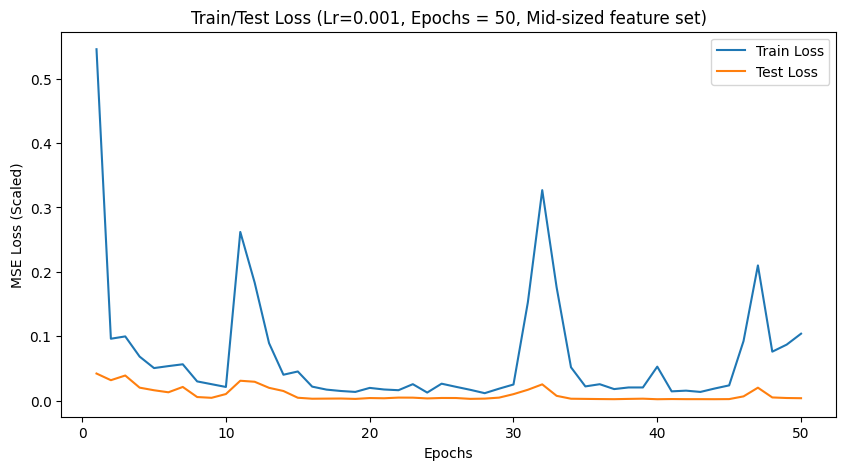

In [31]:
# Plot train/test loss over epochs
plt.figure(figsize=(10, 5))
plt.plot(range(1, best_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, best_epochs + 1), test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss (Scaled)')
plt.title('Train/Test Loss (Lr=0.001, Epochs = 50, Mid-sized feature set)')
plt.legend()
plt.show()

Just looking based on the learning curve graph, it looks like there is not much gain from the additional epochs. The model does pretty well initially after just a few epochs, where the training loss more or less hits the lowest it will go and the test loss settles in before 10 epochs are done.

The repeated spikes in the training loss indicate that possibly the model is hitting a local minimum and is just making the same moves back and forth in it, since the spikes seem to happen somewhat consistently every 20 epochs. Even though this model scored the best through cross-validation, comparing the dictionary of the best values, it was only marginally better than the 10 epoch model, further strengthening the idea that the additional epochs did not really add much here.

In [32]:
# Save the best model weights
torch.save(final_model.state_dict(), 'best_zillow_model.pth')
print("Model saved to 'best_zillow_model.pth'")

Model saved to 'best_zillow_model.pth'


In [34]:
# Save version of full dataset with only the features used in the final model.
X_full = df_zillow_encoded[best_features].values
X_full_scaled = scaler_X_best.transform(X_full)

# Convert to PyTorch tensor
X_full_tensor = torch.tensor(X_full_scaled, dtype=torch.float32).to(device)

# Predict prices for all houses in the data
final_model.eval()
with torch.no_grad():
    preds_full_scaled = final_model(X_full_tensor).cpu().numpy()

# Undo scaling to get actual dollar values.
preds_full_dollars = scaler_y.inverse_transform(preds_full_scaled)

# Create comparison for actual vs. predicted price
df_comparison = pd.DataFrame({
    ''
    'Actual Price': df_zillow_encoded['price'].values,
    'Predicted Price': preds_full_dollars.flatten()
})
df_comparison['Difference'] = df_comparison['Actual Price'] - df_comparison['Predicted Price']

df_comparison.head(15)

,Actual Price,Predicted Price,Difference
0,"$447,000.00","$455,378.41","$-8,378.41"
1,"$1,718,000.00","$1,627,647.88","$90,352.12"
2,"$995,000.00","$1,013,841.25","$-18,841.25"
3,"$349,900.00","$337,956.62","$11,943.38"
4,"$989,999.00","$1,011,919.50","$-21,920.50"
5,"$1,070,000.00","$1,104,142.38","$-34,142.38"
6,"$1,899,000.00","$1,926,820.75","$-27,820.75"
7,"$459,000.00","$442,496.41","$16,503.59"
8,"$1,095,000.00","$1,267,996.38","$-172,996.38"
9,"$699,000.00","$710,420.19","$-11,420.19"


In [35]:
df_comparison.Difference.min()

-1269263.0

In [36]:
df_comparison.Difference.max()

4106388.0

In [37]:
df_comparison.describe()

,Actual Price,Predicted Price,Difference
count,$887.00,$887.00,$887.00
mean,"$753,418.56","$759,842.19","$-6,423.66"
std,"$1,863,034.12","$1,885,785.50","$194,881.16"
min,"$55,000.00","$-24,277.03","$-1,269,263.00"
25%,"$349,450.00","$333,644.84","$-22,295.91"
50%,"$495,000.00","$494,666.88","$2,986.88"
75%,"$750,000.00","$762,365.59","$23,601.33"
max,"$45,000,000.00","$45,283,008.00","$4,106,388.00"


Possible todo items:

* Use the predicted values to see if there are any consistencies from the predictions that did the worst. The max and min seem pretty egregious, but the mean difference is only -$6,423.66, which is quite good given the high price values of homes, so it is likely the effect of outliers which could be filtered out to see if that improves performance.
* Work on some feature engineering, see if anything improves model performance. To be honest, the mean being quite low and the loss being pretty low pretty quickly paired with the information about the Difference makes me think that the model actually learned the data quite well but is stuck on a few outliers. But still worth an exploration, if for just some extra practice.
* Play with model architecture - This may be a bit out of scope for this particular project in this class, but there is a good chance to squeeze out a bit more performance by just expanding the network a bit, since this is a relatively small network (layers of 64 and 32 respectively).